In [1]:
import time
from edu1sces.model import HeisenbergModel
from edu1sces.solver import solve, SolverParameters
import matplotlib.pyplot as plt

In [2]:
N = 20
total_sz = 0
model = HeisenbergModel(
    spins={i: 0.5 for i in range(N)},
    exchange_xy={(i, (i + 1)): 1.0 for i in range(N - 1)},
    exchange_z={(i, (i + 1)): 1.0 for i in range(N - 1)},
)
params = SolverParameters(num_states=3, output_log=True, num_threads=6)
result = solve(model, total_sz=total_sz, params=params)
print(f"Energy: {result.energies}")

Building basis...
Done in 0.0s (6 threads)
Building Hamiltonian...
Done in 0.1s (6 threads)
Diagonalizing Hamiltonian (ground state)...
Done in 0.2s (6 threads)                          
Improving eigenvector...
Done in 0.0s (6 threads)                          
Diagonalizing Hamiltonian (excited state 1)...
Done in 0.2s (6 threads)                          
Improving eigenvector...
Done in 0.1s (6 threads)                          
Diagonalizing Hamiltonian (excited state 2)...
Done in 0.3s (6 threads)                          
Improving eigenvector...
Done in 0.1s (6 threads)                          
Energy: [-8.682473334398964, -8.502378698046849, -8.280104590352513]


In [3]:
# Total S^2 の期待値を計算する関数
def compute_total_S2(model, result, state_index):
    """
    ⟨S^2⟩ = N * 3/4 + Σ_{i≠j} ⟨S_i · S_j⟩
          = N * 3/4 + 2 * Σ_{i<j} (⟨Sx_i Sx_j⟩ + ⟨Sy_i Sy_j⟩ + ⟨Sz_i Sz_j⟩)
    
    Note: Sy = -i * (iSy), so ⟨Sy_i Sy_j⟩ = -⟨(iSy_i)(iSy_j)⟩
    """
    N = model.num_sites
    # 単サイト寄与: N * S(S+1) = N * 3/4 (spin-1/2)
    S2 = N * 0.75
    
    # 2サイト寄与
    for i in range(N):
        for j in range(i + 1, N):
            Sx_i = model.make_local_op_sx(i)
            Sx_j = model.make_local_op_sx(j)
            iSy_i = model.make_local_op_isy(i)
            iSy_j = model.make_local_op_isy(j)
            Sz_i = model.make_local_op_sz(i)
            Sz_j = model.make_local_op_sz(j)
            
            SxSx = result.correlation_function(Sx_i, i, Sx_j, j, state_index)
            SySy = -result.correlation_function(iSy_i, i, iSy_j, j, state_index)  # Sy = -i*(iSy)
            SzSz = result.correlation_function(Sz_i, i, Sz_j, j, state_index)
            
            SiSj = SxSx + SySy + SzSz
            S2 += 2 * SiSj  # i<j と j<i の両方
    
    return S2

In [4]:
# 各状態の ⟨S^2⟩ を計算
print("各固有状態の Total S^2 期待値:")
print("-" * 40)
for state_idx in range(len(result.energies)):
    S2 = compute_total_S2(model, result, state_idx)
    # S(S+1) = S2 から S を求める: S = (-1 + sqrt(1 + 4*S2)) / 2
    import math
    S = (-1 + math.sqrt(1 + 4 * S2)) / 2
    print(f"State {state_idx}: E = {result.energies[state_idx]:.6f}, ⟨S²⟩ = {S2:.6f}, S ≈ {S:.3f}")

各固有状態の Total S^2 期待値:
----------------------------------------
State 0: E = -8.682473, ⟨S²⟩ = 0.000000, S ≈ 0.000
State 1: E = -8.502379, ⟨S²⟩ = 2.000000, S ≈ 1.000
State 2: E = -8.280105, ⟨S²⟩ = 2.000000, S ≈ 1.000


In [5]:
Sz_cfs = []
time_start = time.perf_counter()
for i in range(1, N):
    Sz_0 = model.make_local_op_sz(0)
    Sz_i = model.make_local_op_sz(i)
    Sz_cfs.append(result.correlation_function(Sz_0, 0, Sz_i, i, 1))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

Elapsed time: 0.03905666701029986 sec


In [6]:
Sx_cfs = []
time_start = time.perf_counter()
for i in range(1, N):
    Sx_0 = model.make_local_op_sx(0)
    Sx_i = model.make_local_op_sx(i)
    Sx_cfs.append(result.correlation_function(Sx_0, 0, Sx_i, i, 1))
time_end = time.perf_counter()
print(f"Elapsed time: {time_end - time_start} sec")

Elapsed time: 0.08252625001478009 sec


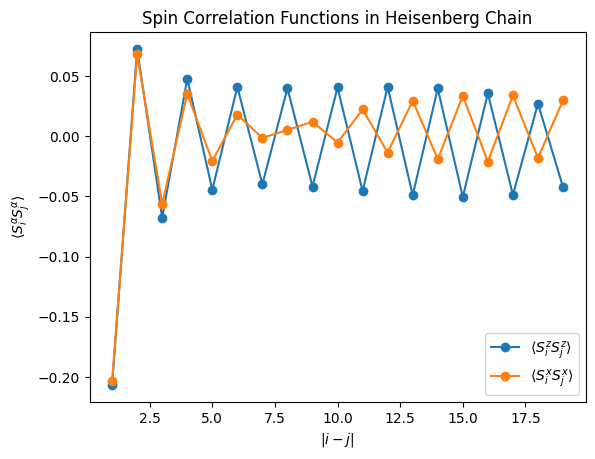

In [7]:
plt.plot(range(1, N), Sz_cfs, marker="o", label=r"$\langle S_i^z S_j^z \rangle$")
plt.plot(range(1, N), Sx_cfs, marker="o", label=r"$\langle S_i^x S_j^x \rangle$")
plt.xlabel(r"$|i-j|$")
plt.ylabel(r"$\langle S_i^\alpha S_j^\alpha \rangle$")
plt.title("Spin Correlation Functions in Heisenberg Chain")
plt.legend()

In [8]:
# 各セクターで相関関数を計算して平均
def compute_correlations(model, result, state_index):
    Sz_cfs = []
    Sx_cfs = []
    N = model.num_sites
    for i in range(1, N):
        Sz_0 = model.make_local_op_sz(0)
        Sz_i = model.make_local_op_sz(i)
        Sx_0 = model.make_local_op_sx(0)
        Sx_i = model.make_local_op_sx(i)
        Sz_cfs.append(result.correlation_function(Sz_0, 0, Sz_i, i, state_index))
        Sx_cfs.append(result.correlation_function(Sx_0, 0, Sx_i, i, state_index))
    return Sz_cfs, Sx_cfs

# total_sz = 0 の第一励起状態 (既に計算済み)
Sz_m0, Sx_m0 = Sz_cfs, Sx_cfs  # state_index=1 で計算済み

# total_sz = +1, -1 で基底状態を計算
params_single = SolverParameters(num_states=1, output_log=False, num_threads=6)
result_sz1 = solve(model, total_sz=1, params=params_single)
result_sz_minus1 = solve(model, total_sz=-1, params=params_single)

print(f"total_sz=+1: E = {result_sz1.energies[0]:.6f}")
print(f"total_sz= 0: E = {result.energies[1]:.6f}")
print(f"total_sz=-1: E = {result_sz_minus1.energies[0]:.6f}")

Sz_m1, Sx_m1 = compute_correlations(model, result_sz1, 0)
Sz_m_minus1, Sx_m_minus1 = compute_correlations(model, result_sz_minus1, 0)

total_sz=+1: E = -8.502379
total_sz= 0: E = -8.502379
total_sz=-1: E = -8.502379


In [9]:
# 3つのセクターで平均
import numpy as np

Sz_avg = (np.array(Sz_m1) + np.array(Sz_m0) + np.array(Sz_m_minus1)) / 3
Sx_avg = (np.array(Sx_m1) + np.array(Sx_m0) + np.array(Sx_m_minus1)) / 3

print("S=1 三重項の平均相関関数:")
print("距離 | ⟨Sz Sz⟩_avg  | ⟨Sx Sx⟩_avg  | 差")
print("-" * 55)
for i, (sz, sx) in enumerate(zip(Sz_avg, Sx_avg)):
    print(f"{i+1:4d} | {sz:12.8f} | {sx:12.8f} | {abs(sz-sx):.2e}")

S=1 三重項の平均相関関数:
距離 | ⟨Sz Sz⟩_avg  | ⟨Sx Sx⟩_avg  | 差
-------------------------------------------------------
   1 |  -0.20470146 |  -0.20470146 | 5.08e-15
   2 |   0.06967642 |   0.06967642 | 5.55e-17
   3 |  -0.06005936 |  -0.06005936 | 8.05e-16
   4 |   0.03952003 |   0.03952003 | 1.38e-15
   5 |  -0.02846044 |  -0.02846044 | 3.12e-16
   6 |   0.02576356 |   0.02576356 | 6.63e-16
   7 |  -0.01416336 |  -0.01416336 | 3.82e-16
   8 |   0.01687414 |   0.01687414 | 9.96e-16
   9 |  -0.00579358 |  -0.00579358 | 3.75e-16
  10 |   0.01011458 |   0.01011458 | 1.27e-15
  11 |  -0.00028627 |  -0.00028627 | 2.43e-16
  12 |   0.00473181 |   0.00473181 | 2.26e-15
  13 |   0.00339472 |   0.00339472 | 4.02e-16
  14 |   0.00063371 |   0.00063371 | 1.01e-15
  15 |   0.00560051 |   0.00560051 | 5.38e-16
  16 |  -0.00201609 |  -0.00201609 | 4.84e-16
  17 |   0.00642812 |   0.00642812 | 2.65e-15
  18 |  -0.00288955 |  -0.00288955 | 1.81e-15
  19 |   0.00585589 |   0.00585589 | 2.10e-15


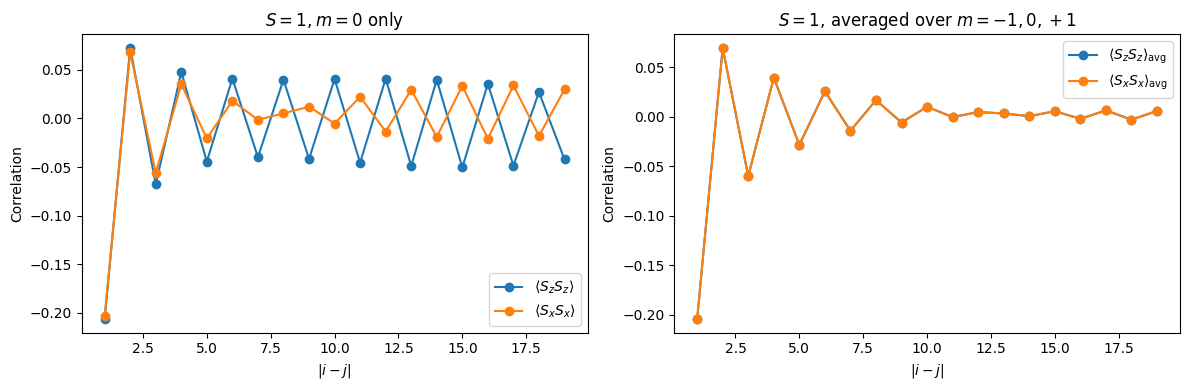

In [10]:
# プロット: 平均前と平均後の比較
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左: total_sz=0 のみ (平均前)
axes[0].plot(range(1, N), Sz_m0, marker="o", label=r"$\langle S_z S_z \rangle$")
axes[0].plot(range(1, N), Sx_m0, marker="o", label=r"$\langle S_x S_x \rangle$")
axes[0].set_xlabel(r"$|i-j|$")
axes[0].set_ylabel("Correlation")
axes[0].set_title(r"$S=1, m=0$ only")
axes[0].legend()

# 右: 3セクター平均後
axes[1].plot(range(1, N), Sz_avg, marker="o", label=r"$\langle S_z S_z \rangle_{\rm avg}$")
axes[1].plot(range(1, N), Sx_avg, marker="o", label=r"$\langle S_x S_x \rangle_{\rm avg}$")
axes[1].set_xlabel(r"$|i-j|$")
axes[1].set_ylabel("Correlation")
axes[1].set_title(r"$S=1$, averaged over $m=-1,0,+1$")
axes[1].legend()

plt.tight_layout()